**Purpose:** Aggregate v2 cross-validation results.

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [1]:
import json
import pandas as pd
import os

In [2]:
sectoremb = [x for x in os.listdir("cv_results_v2/sectoremb") if x.endswith(".json")]
tfidfemb = [x for x in os.listdir("cv_results_v2/tfidfemb") if x.endswith(".json")]
bertemb = [x for x in os.listdir("cv_results_v2/bertemb") if x.endswith(".json")]

len(sectoremb), len(tfidfemb), len(bertemb)

(20, 15, 3)

In [3]:
sectoremb_results = {}
for file in sectoremb:
    with open(os.path.join("cv_results_v2/sectoremb", file), "r") as f:
        data = json.load(f)["fold_results"]
        sectoremb_results[file.replace("_results.json", "")] = data

tfidfemb_results = {}
for file in tfidfemb:
    with open(os.path.join("cv_results_v2/tfidfemb", file), "r") as f:
        data = json.load(f)["fold_results"]
        tfidfemb_results[file.replace("_results.json", "")] = data

bertemb_results = {}
for file in bertemb:
    with open(os.path.join("cv_results_v2/bertemb", file), "r") as f:
        data = json.load(f)["fold_results"]
        bertemb_results[file.replace("_results.json", "")] = data

In [4]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

def plot_global_macro_f1(data, title="GLOBAL Macro-F1 across folds (Validation vs Test)"):
    records = []

    # --- Convert dict → flat table ---
    for cfg, folds in data.items():
        for fold_info in folds:
            rec = {
                "config": cfg,
                "fold": fold_info["fold"],
                "train": fold_info["train_macro_f1"],
                "val": fold_info["val_macro_f1"],
            }
            records.append(rec)

    df = pd.DataFrame(records).sort_values(["config", "fold"])

    # --- Plot ---
    colors = px.colors.qualitative.Set2
    fig = go.Figure()

    for i, cfg in enumerate(df["config"].unique()):
        d = df[df["config"] == cfg]
        color = colors[i % len(colors)]

        # Validation (solid)
        fig.add_trace(go.Scatter(
            x=d["fold"],
            y=d["val"],
            mode="lines+markers",
            name=f"{cfg} | val",
            legendgroup=cfg,
            line=dict(color=color)
        ))

        # Test (dashed, same color)
        fig.add_trace(go.Scatter(
            x=d["fold"],
            y=d["train"],
            mode="lines+markers",
            name=f"{cfg} | train",
            legendgroup=cfg,
            line=dict(color=color, dash="dash"),
            showlegend=False
        ))

    fig.update_layout(
        title=title,
        xaxis_title="Fold",
        yaxis_title="Macro-F1",
        hovermode="x unified",

        legend=dict(
            orientation="h",          # horizontal legend
            yanchor="bottom",
            y=-1.12,                   # move above plot
            xanchor="center",
            x=0.5
        ),
    )

    fig.update_layout(
        width=1000,
        height=900
    )

    fig.update_yaxes(range=[0.7, 0.9])

    fig.show()

In [5]:
plot_global_macro_f1(sectoremb_results, title="Sector Embeddings: GLOBAL Macro-F1 across folds (Train vs Validation)")
plot_global_macro_f1(tfidfemb_results, title="TF-IDF Embeddings: GLOBAL Macro-F1 across folds (Train vs Validation)")
plot_global_macro_f1(bertemb_results, title="FinBERT Embeddings: GLOBAL Macro-F1 across folds (Train vs Validation)")

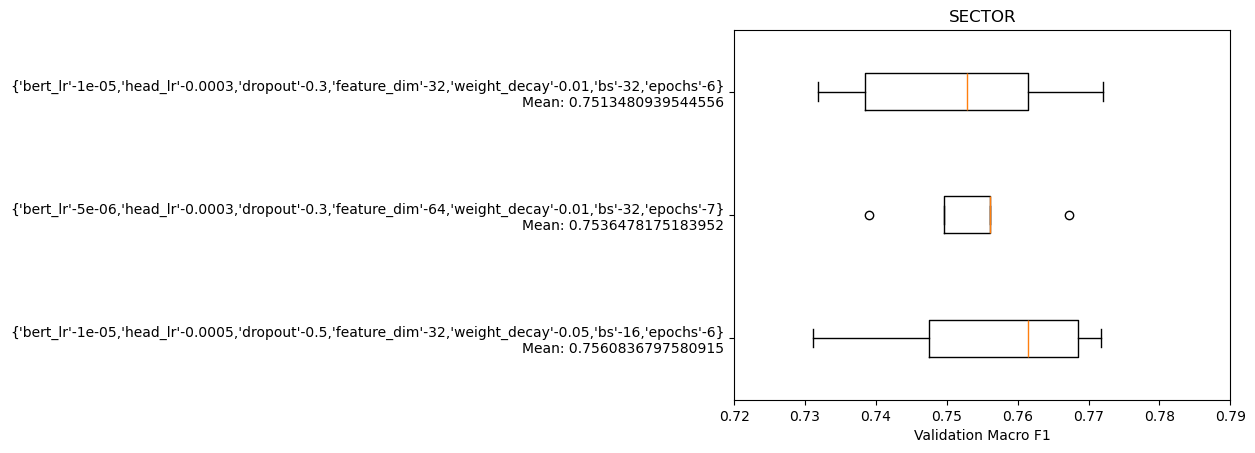

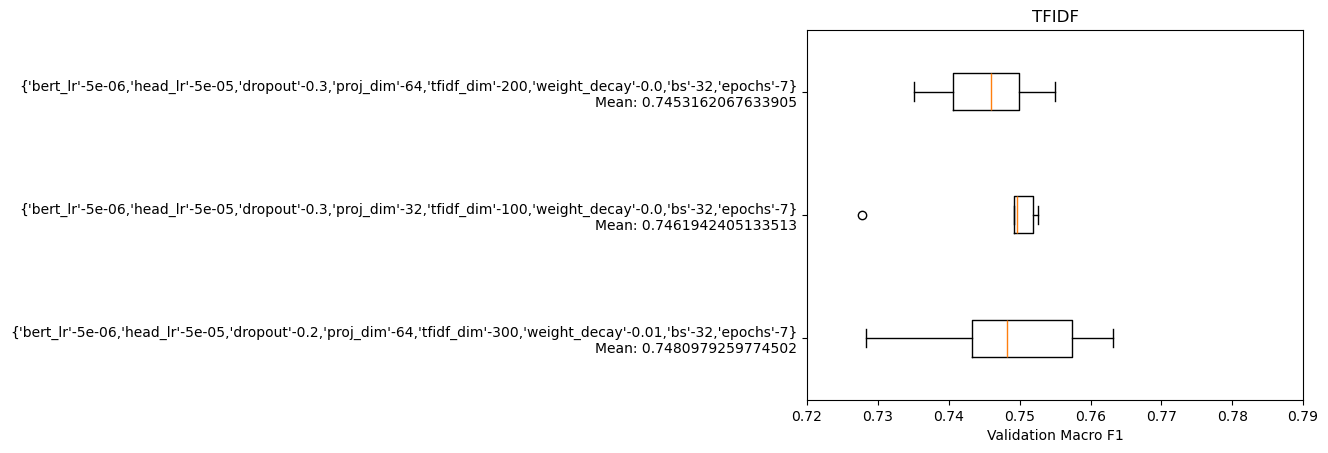

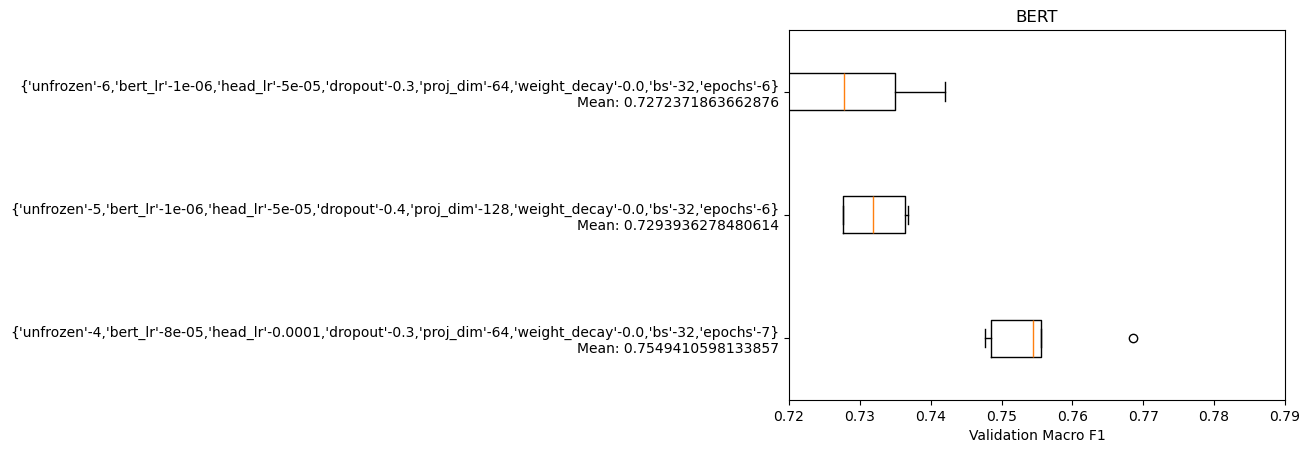

In [6]:
import matplotlib.pyplot as plt

def boxpllot_result(results, tilte=""):
    # --- recompute top 5 by mean val F1 ---
    mean_scores = []
    for config, folds in results.items():
        val_scores = [f['val_macro_f1'] for f in folds]
        mean_scores.append((config, sum(val_scores)/len(val_scores)))

    top5_configs = sorted(mean_scores, key=lambda x: x[1], reverse=True)[:3]

    # --- prepare data ---
    boxplot_data = []
    labels = []

    for config, _ in top5_configs:
        vals = [f['val_macro_f1'] for f in results[config]]
        boxplot_data.append(vals)
        labels.append(config + f"\nMean: {np.mean(vals)}")  # full label

    # --- horizontal boxplot ---
    plt.figure()
    plt.boxplot(boxplot_data, vert=False)
    plt.yticks(range(1, len(labels)+1), labels)
    plt.xlim(0.72, 0.79)
    plt.xlabel("Validation Macro F1")
    plt.title(tilte)
    plt.show()

boxpllot_result(sectoremb_results, "SECTOR")
boxpllot_result(tfidfemb_results, "TFIDF")
boxpllot_result(bertemb_results, "BERT")

escolher o q tem maior validacao?

é que por exemplo no bert o que tem maior validacao tem enorme overfitting...

**proposta:** ordenar pelos melhores modelos e o primeiro com learninc curve aceitavel é o que uso?